<a href="https://colab.research.google.com/github/atharv-d21/traffic_demand_prediction/blob/main/traffic_demand_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# importing dependancies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import mean_squared_error

In [2]:
# loading datasets
training_dataset = pd.read_csv('https://raw.githubusercontent.com/atharv-d21/traffic_demand_prediction/refs/heads/main/datasets/train.csv')
testing_dataset = pd.read_csv('https://raw.githubusercontent.com/atharv-d21/traffic_demand_prediction/refs/heads/main/datasets/test.csv')
training_dataset.head(5)

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


# DATA ANALYSIS

In [3]:
training_dataset['day'].unique()

array([48, 49])

In [4]:
training_dataset['RoadType'].unique()

array([nan, 'Residential', 'Street', 'Highway'], dtype=object)

In [5]:
training_dataset['NumberofLanes'].unique()

array([1, 3, 2, 4, 5])

In [6]:
training_dataset['LargeVehicles'].unique()

array(['Not Allowed', 'Allowed'], dtype=object)

In [7]:
training_dataset['Landmarks'].unique()

array(['No', 'Yes'], dtype=object)

In [8]:
training_dataset['Temperature'].unique()

array([        nan, 31.1045646 , 25.91926732, ..., 19.67885975,
       22.57395805,  1.32203433])

In [9]:
training_dataset['Temperature'].max()

48.2514326535093

In [10]:
training_dataset['Weather'].unique()

array([nan, 'Sunny', 'Rainy', 'Foggy', 'Snowy'], dtype=object)

In [11]:
training_dataset['demand'].min(), training_dataset['demand'].max()

(6.245650130093708e-07, 1.0)

In [12]:
training_dataset['Index'][training_dataset['Temperature']==training_dataset['Temperature'].min()]

,Index
8636,8636


In [13]:
training_dataset['RoadType'].value_counts(dropna=False)

,count
RoadType,
Residential,69230
Street,3909
Highway,3560
NaN,600


In [14]:
training_dataset['Weather'].value_counts(dropna=False)

,count
Weather,
Sunny,27717
Rainy,20824
Foggy,20243
Snowy,7718
NaN,797


# FEATURE ENGINEERING

In [15]:
# spliting the 'geohast' into multiple features
training_dataset['geohash_prefix'] = training_dataset['geohash'].str[:3]
training_dataset['geohash_location'] = training_dataset['geohash'].str[3:]

testing_dataset['geohash_prefix'] = testing_dataset['geohash'].str[:3]
testing_dataset['geohash_location'] = testing_dataset['geohash'].str[3:]

display(training_dataset.head(5))

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,geohash_prefix,geohash_location
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN,qp0,2z1
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny,qp0,2zt
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny,qp0,8bj
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy,qp0,8gt
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy,qp0,2zq


In [16]:
training_dataset['geohash_location'].value_counts()

,count
geohash_location,
3wd,105
3wf,105
9t0,105
3w9,105
3x3,105
...,...
8gs,1
8fq,1
d1t,1


In [17]:
# spliting the 'geohash_location' into multiple feature to be more specific
training_dataset['geohash_sublocation0'] = training_dataset['geohash_location'].str[0]
training_dataset['geohash_sublocation1'] = training_dataset['geohash_location'].str[1]
training_dataset['geohash_sublocation2'] = training_dataset['geohash_location'].str[2]

testing_dataset['geohash_sublocation0'] = testing_dataset['geohash_location'].str[0]
testing_dataset['geohash_sublocation1'] = testing_dataset['geohash_location'].str[1]
testing_dataset['geohash_sublocation2'] = testing_dataset['geohash_location'].str[2]

training_dataset.head(5)

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,geohash_prefix,geohash_location,geohash_sublocation0,geohash_sublocation1,geohash_sublocation2
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN,qp0,2z1,2,z,1
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny,qp0,2zt,2,z,t
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny,qp0,8bj,8,b,j
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy,qp0,8gt,8,g,t
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy,qp0,2zq,2,z,q


In [18]:
training_dataset['geohash_sublocation0'].value_counts()

,count
geohash_sublocation0,
9,41391
3,23835
d,6175
6,2511
8,1953
2,1434


In [19]:
training_dataset['geohash_sublocation1'].value_counts()

,count
geohash_sublocation1,
z,3821
p,3706
x,3275
w,3183
r,3146
t,2937
0,2898
4,2887
g,2815


In [20]:
training_dataset['geohash_sublocation2'].value_counts()

,count
geohash_sublocation2,
q,3030
w,2967
t,2844
e,2754
y,2727
m,2716
k,2645
b,2566
x,2532


In [21]:
# dropping 'geohash', 'geohash_prefix', 'geohash_location'
training_dataset.drop(['geohash', 'geohash_prefix', 'geohash_location'], axis=1, inplace=True)
testing_dataset.drop(['geohash', 'geohash_prefix', 'geohash_location'], axis=1, inplace=True)

training_dataset.head(5)

,Index,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,geohash_sublocation0,geohash_sublocation1,geohash_sublocation2
0,0,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN,2,z,1
1,1,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny,2,z,t
2,2,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny,8,b,j
3,3,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy,8,g,t
4,4,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy,2,z,q


In [22]:
training_dataset[['hour', 'minute']] = training_dataset['timestamp'].str.split(':', expand=True)
testing_dataset[['hour', 'minute']] = testing_dataset['timestamp'].str.split(':', expand=True)

# Convert 'hour' and 'minute' to numeric types
training_dataset['hour'] = pd.to_numeric(training_dataset['hour'])
training_dataset['minute'] = pd.to_numeric(training_dataset['minute'])
testing_dataset['hour'] = pd.to_numeric(testing_dataset['hour'])
testing_dataset['minute'] = pd.to_numeric(testing_dataset['minute'])

display(training_dataset.head(5))

,Index,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,geohash_sublocation0,geohash_sublocation1,geohash_sublocation2,hour,minute
0,0,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN,2,z,1,0,0
1,1,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny,2,z,t,0,0
2,2,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny,8,b,j,0,0
3,3,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy,8,g,t,0,0
4,4,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy,2,z,q,0,0


In [23]:
# dropping 'timestamp'
training_dataset.drop(['timestamp'], axis=1, inplace=True)
testing_dataset.drop(['timestamp'], axis=1, inplace=True)

training_dataset.head(5)

,Index,day,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,geohash_sublocation0,geohash_sublocation1,geohash_sublocation2,hour,minute
0,0,48,0.048804,NaN,1,Not Allowed,No,NaN,NaN,2,z,1,0,0
1,1,48,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny,2,z,t,0,0
2,2,48,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny,8,b,j,0,0
3,3,48,0.003272,Residential,1,Not Allowed,No,NaN,Rainy,8,g,t,0,0
4,4,48,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy,2,z,q,0,0


In [24]:
# --- Part of Day Feature ---
def get_part_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

training_dataset['part_of_day'] = training_dataset['hour'].apply(get_part_of_day)
testing_dataset['part_of_day'] = testing_dataset['hour'].apply(get_part_of_day)

display(training_dataset.head())

,Index,day,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,geohash_sublocation0,geohash_sublocation1,geohash_sublocation2,hour,minute,part_of_day
0,0,48,0.048804,NaN,1,Not Allowed,No,NaN,NaN,2,z,1,0,0,Night
1,1,48,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny,2,z,t,0,0,Night
2,2,48,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny,8,b,j,0,0,Night
3,3,48,0.003272,Residential,1,Not Allowed,No,NaN,Rainy,8,g,t,0,0,Night
4,4,48,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy,2,z,q,0,0,Night


In [25]:
# fill null values with 'Unknown'
training_dataset['RoadType'] = training_dataset['RoadType'].fillna("Unknown")
testing_dataset['RoadType'] = testing_dataset['RoadType'].fillna("Unknown")

training_dataset['Weather'] = training_dataset['Weather'].fillna("Unknown")
testing_dataset['Weather'] = testing_dataset['Weather'].fillna("Unknown")

In [26]:
training_dataset['LargeVehicles'] = training_dataset['LargeVehicles'].replace({'Allowed': 1, 'Not Allowed': 0})
testing_dataset['LargeVehicles'] = testing_dataset['LargeVehicles'].replace({'Allowed': 1, 'Not Allowed': 0})

training_dataset['Landmarks'] = training_dataset['Landmarks'].replace({'Yes': 1, 'No': 0})
testing_dataset['Landmarks'] = testing_dataset['Landmarks'].replace({'Yes': 1, 'No': 0})

/tmp/ipykernel_7060/30838673.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  training_dataset['LargeVehicles'] = training_dataset['LargeVehicles'].replace({'Allowed': 1, 'Not Allowed': 0})
/tmp/ipykernel_7060/30838673.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  testing_dataset['LargeVehicles'] = testing_dataset['LargeVehicles'].replace({'Allowed': 1, 'Not Allowed': 0})
/tmp/ipykernel_7060/30838673.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the

In [27]:
training_dataset['Temperature'] = training_dataset.groupby('Weather')['Temperature'].transform(lambda x: x.fillna(x.mean()))
testing_dataset['Temperature'] = testing_dataset.groupby('Weather')['Temperature'].transform(lambda x: x.fillna(x.mean()))

display(training_dataset.head(5))

,Index,day,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,geohash_sublocation0,geohash_sublocation1,geohash_sublocation2,hour,minute,part_of_day
0,0,48,0.048804,Unknown,1,0,0,16.750642,Unknown,2,z,1,0,0,Night
1,1,48,0.118507,Residential,3,1,1,31.104565,Sunny,2,z,t,0,0,Night
2,2,48,0.027132,Residential,1,0,0,25.919267,Sunny,8,b,j,0,0,Night
3,3,48,0.003272,Residential,1,0,0,10.934935,Rainy,8,g,t,0,0,Night
4,4,48,0.010819,Residential,1,0,0,10.803667,Rainy,2,z,q,0,0,Night


In [28]:
training_dataset['active_hours'] = ((training_dataset['hour'] >= 8) & (training_dataset['hour'] <= 11)) | \
                                   ((training_dataset['hour'] >= 17) & (training_dataset['hour'] <= 20))

testing_dataset['active_hours'] = ((testing_dataset['hour'] >= 8) & (testing_dataset['hour'] <= 11)) | \
                                  ((testing_dataset['hour'] >= 17) & (testing_dataset['hour'] <= 20))

# Convert boolean to integer (1 or 0)
training_dataset['active_hours'] = training_dataset['active_hours'].astype(int)
testing_dataset['active_hours'] = testing_dataset['active_hours'].astype(int)

training_dataset.head(5)

,Index,day,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,geohash_sublocation0,geohash_sublocation1,geohash_sublocation2,hour,minute,part_of_day,active_hours
0,0,48,0.048804,Unknown,1,0,0,16.750642,Unknown,2,z,1,0,0,Night,0
1,1,48,0.118507,Residential,3,1,1,31.104565,Sunny,2,z,t,0,0,Night,0
2,2,48,0.027132,Residential,1,0,0,25.919267,Sunny,8,b,j,0,0,Night,0
3,3,48,0.003272,Residential,1,0,0,10.934935,Rainy,8,g,t,0,0,Night,0
4,4,48,0.010819,Residential,1,0,0,10.803667,Rainy,2,z,q,0,0,Night,0


In [29]:
# Identify categorical columns to encode
categorical_cols = ['RoadType', 'Weather', 'part_of_day', 'geohash_sublocation0', 'geohash_sublocation1', 'geohash_sublocation2']

# One-hot encode the training and testing sets
training_dataset = pd.get_dummies(training_dataset, columns=categorical_cols)
testing_dataset = pd.get_dummies(testing_dataset, columns=categorical_cols)

# Ensure both dataframes have the same columns after encoding
# (Aligns test set to train set columns, filling missing with 0)
testing_dataset = testing_dataset.reindex(columns=[col for col in training_dataset.columns if col != 'demand'], fill_value=0)

training_dataset.head()

,Index,day,demand,NumberofLanes,LargeVehicles,Landmarks,Temperature,hour,minute,active_hours,...,geohash_sublocation2_q,geohash_sublocation2_r,geohash_sublocation2_s,geohash_sublocation2_t,geohash_sublocation2_u,geohash_sublocation2_v,geohash_sublocation2_w,geohash_sublocation2_x,geohash_sublocation2_y,geohash_sublocation2_z
0,0,48,0.048804,1,0,0,16.750642,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,1,48,0.118507,3,1,1,31.104565,0,0,0,...,False,False,False,True,False,False,False,False,False,False
2,2,48,0.027132,1,0,0,25.919267,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,3,48,0.003272,1,0,0,10.934935,0,0,0,...,False,False,False,True,False,False,False,False,False,False
4,4,48,0.010819,1,0,0,10.803667,0,0,0,...,True,False,False,False,False,False,False,False,False,False


In [30]:
# Calculate correlations with the 'demand' column
correlations = training_dataset.corr()['demand'].sort_values(ascending=False)

# Display the correlations
print("Correlation of features with demand:")
print(correlations)

Correlation of features with demand:
demand                    1.000000
RoadType_Highway          0.798625
RoadType_Street           0.290896
geohash_sublocation1_d    0.220263
NumberofLanes             0.214148
                            ...   
geohash_sublocation1_m   -0.076348
geohash_sublocation0_6   -0.087305
part_of_day_Evening      -0.087790
geohash_sublocation0_d   -0.096906
RoadType_Residential     -0.756704
Name: demand, Length: 93, dtype: float64


In [31]:
# 1. Identify top 10 best and worst features (excluding 'demand' itself)
corr_series = training_dataset.corr()['demand'].drop('demand')
best_10 = corr_series.sort_values(ascending=False).head(10)
worst_10 = corr_series.sort_values(ascending=True).head(10)

# 2. Create 'best_features' (weighted sum of top 10 positive correlations)
training_dataset['best_features'] = training_dataset[best_10.index].mul(best_10).sum(axis=1)
testing_dataset['best_features'] = testing_dataset[best_10.index].mul(best_10).sum(axis=1)

# 3. Create 'worst_features' (weighted sum of top 10 negative correlations)
training_dataset['worst_features'] = training_dataset[worst_10.index].mul(worst_10).sum(axis=1)
testing_dataset['worst_features'] = testing_dataset[worst_10.index].mul(worst_10).sum(axis=1)

print("Top 10 Best Features applied:", list(best_10.index))
print("Top 10 Worst Features applied:", list(worst_10.index))
training_dataset[['best_features', 'worst_features', 'demand']].head()

Top 10 Best Features applied: ['RoadType_Highway', 'RoadType_Street', 'geohash_sublocation1_d', 'NumberofLanes', 'LargeVehicles', 'geohash_sublocation1_6', 'geohash_sublocation1_x', 'geohash_sublocation1_e', 'part_of_day_Morning', 'geohash_sublocation0_9']
Top 10 Worst Features applied: ['RoadType_Residential', 'geohash_sublocation0_d', 'part_of_day_Evening', 'geohash_sublocation0_6', 'geohash_sublocation1_m', 'geohash_sublocation1_t', 'geohash_sublocation1_p', 'geohash_sublocation1_j', 'geohash_sublocation1_1', 'geohash_sublocation1_5']


,best_features,worst_features,demand
0,0.214148,0.000000,0.048804
1,0.836066,-0.756704,0.118507
2,0.214148,-0.756704,0.027132
3,0.214148,-0.756704,0.003272
4,0.214148,-0.756704,0.010819


In [32]:
# Calculate correlations with the 'demand' column
correlations = training_dataset.corr()['demand'].sort_values(ascending=False)

# Display the correlations
print("Correlation of features with demand:")
print(correlations)

Correlation of features with demand:
demand                    1.000000
RoadType_Highway          0.798625
worst_features            0.761949
best_features             0.609555
RoadType_Street           0.290896
                            ...   
geohash_sublocation1_m   -0.076348
geohash_sublocation0_6   -0.087305
part_of_day_Evening      -0.087790
geohash_sublocation0_d   -0.096906
RoadType_Residential     -0.756704
Name: demand, Length: 95, dtype: float64


In [33]:
training_dataset.head(5)

,Index,day,demand,NumberofLanes,LargeVehicles,Landmarks,Temperature,hour,minute,active_hours,...,geohash_sublocation2_s,geohash_sublocation2_t,geohash_sublocation2_u,geohash_sublocation2_v,geohash_sublocation2_w,geohash_sublocation2_x,geohash_sublocation2_y,geohash_sublocation2_z,best_features,worst_features
0,0,48,0.048804,1,0,0,16.750642,0,0,0,...,False,False,False,False,False,False,False,False,0.214148,0.000000
1,1,48,0.118507,3,1,1,31.104565,0,0,0,...,False,True,False,False,False,False,False,False,0.836066,-0.756704
2,2,48,0.027132,1,0,0,25.919267,0,0,0,...,False,False,False,False,False,False,False,False,0.214148,-0.756704
3,3,48,0.003272,1,0,0,10.934935,0,0,0,...,False,True,False,False,False,False,False,False,0.214148,-0.756704
4,4,48,0.010819,1,0,0,10.803667,0,0,0,...,False,False,False,False,False,False,False,False,0.214148,-0.756704


In [34]:
# identifying the features and target for training and evaluation models
features = training_dataset.drop(['demand', 'Index'], axis=1)
target = training_dataset['demand']

test_features = testing_dataset.drop(['Index'], axis=1)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [35]:
# Initialize the XGBoost Regressor model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [36]:
# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model using Mean Squared Error
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
print(f"XGBoost Regressor Mean Squared Error: {mse_xgb}")

XGBoost Regressor Mean Squared Error: 0.002276128701312906


In [37]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
                           param_grid=param_grid,
                           scoring='neg_mean_squared_error',
                           cv=3,  # 3-fold cross-validation
                           n_jobs=-1, # Use all available cores
                           verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 243 candidates, totalling 729 fits


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.8, 1.0],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.7, 0.8, 1.0]},
             scoring='neg_mean_squared_error', verbose=1)

In [38]:
# Print the best parameters and best score
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation MSE: {-grid_search.best_score_}")

# Get the best model
best_xgb_model = grid_search.best_estimator_

# Make predictions on the test set with the best model
y_pred_tuned_xgb = best_xgb_model.predict(X_test)

# Evaluate the tuned model
mse_tuned_xgb = mean_squared_error(y_test, y_pred_tuned_xgb)
print(f"Tuned XGBoost Regressor Mean Squared Error on Test Set: {mse_tuned_xgb}")

Best parameters found: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300, 'subsample': 1.0}
Best cross-validation MSE: 0.0013560038209626008
Tuned XGBoost Regressor Mean Squared Error on Test Set: 0.0011579632457948724


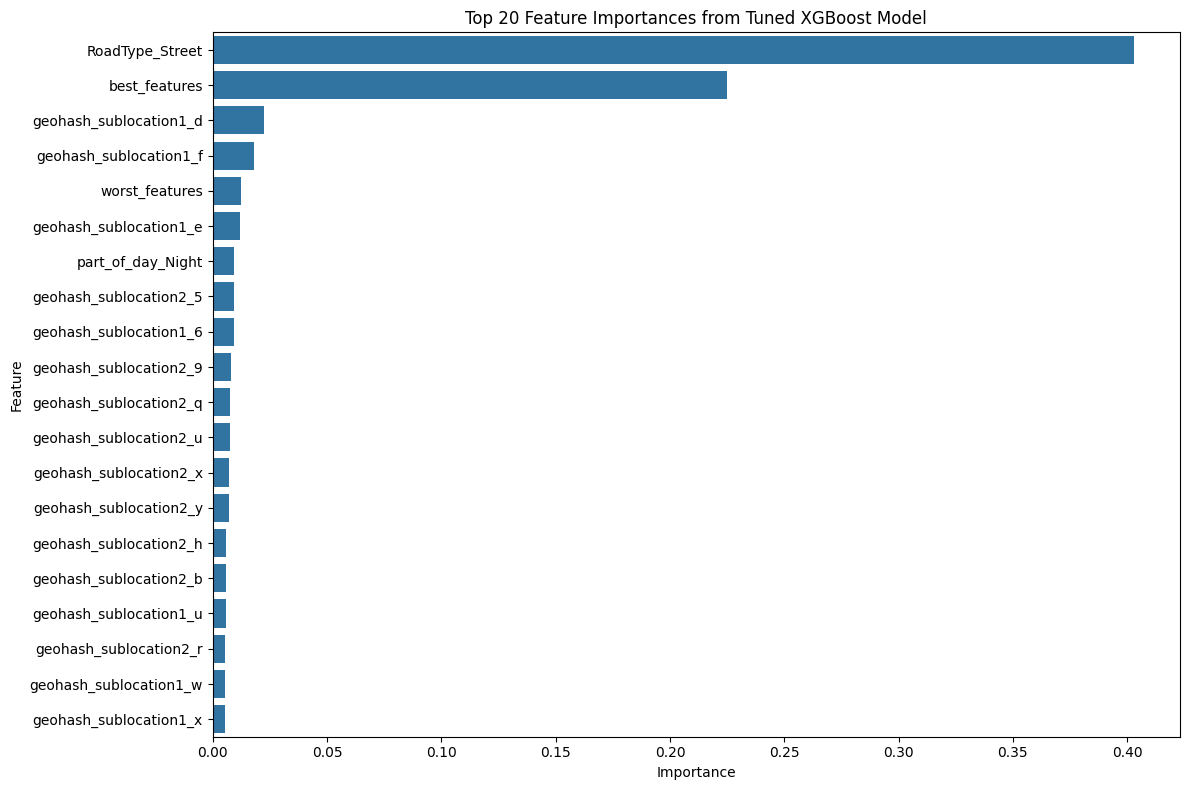

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the best model
feature_importances = best_xgb_model.feature_importances_

# Get feature names from X_train
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort features by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the top N important features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20))
plt.title('Top 20 Feature Importances from Tuned XGBoost Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

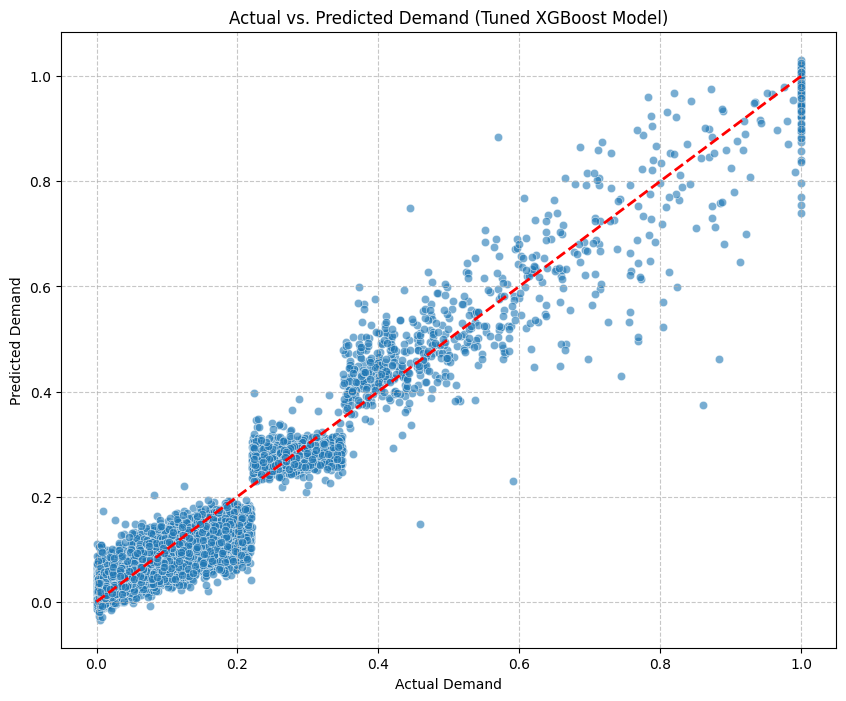

In [40]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred_tuned_xgb, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Perfect prediction line
plt.title('Actual vs. Predicted Demand (Tuned XGBoost Model)')
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [41]:
from sklearn.metrics import r2_score

# Calculate R-squared score for the tuned model
r2 = r2_score(y_test, y_pred_tuned_xgb)

print(f"R-squared score for the tuned XGBoost model: {r2}")

R-squared score for the tuned XGBoost model: 0.9427727670975604


In [42]:
test_predictions = best_xgb_model.predict(test_features)

print("Predictions on the testing dataset have been made.")
print(f"First 5 predictions: {test_predictions[:5]}")

Predictions on the testing dataset have been made.
First 5 predictions: [0.05115327 0.02956165 0.0090096  0.01202153 0.04834304]


In [43]:
submission = pd.DataFrame({
    'Index': testing_dataset['Index'],
    'demand': test_predictions
})

submission.to_csv('submission300502.csv', index=False)

print("Submission file 'submission300502.csv' created successfully.")
print(submission.head())

Submission file 'submission300502.csv' created successfully.
   Index    demand
0      0  0.051153
1      1  0.029562
2      2  0.009010
3      3  0.012022
4      4  0.048343
